# 10 — Cross-dataset analysis

The replication table: for each dataset, the same four questions —
disagreement rate and direction, dataset-level delta, labels-only delta,
unseen-family recall — side by side. This is the table that turns
"interesting, but only CICIDS2017" into a replication claim.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
DRIVE_ROOT = '/content/drive/MyDrive/research/ids-label-correction'
sys.path.insert(0, os.path.join(DRIVE_ROOT, 'src'))

import importlib, config as C, helpers as H
importlib.reload(C); importlib.reload(H)
import pandas as pd, numpy as np, json

runs = pd.read_csv(os.path.join(C.RESULTS, 'runs.csv'))
runs = runs.drop_duplicates(subset='run_id', keep='last')
runs['dataset'] = runs['dataset'].fillna('2017').astype(str).str.replace(r'\.0$', '', regex=True)
runs['task'] = runs['task'].fillna('multiclass')
runs['attempted'] = runs['attempted'].fillna('n/a')   # pandas reads literal 'n/a' as NaN
for m in ['macro_f1', 'attack_recall']:
    runs[m] = pd.to_numeric(runs[m], errors='coerce')
print(runs.groupby(['dataset', 'task', 'arm', 'split']).size().to_string())

Mounted at /content/drive
dataset  task        arm  split       
2017     binary      A    day_ordered     70
                          random_70_30    70
                     B    day_ordered     40
                          random_70_30    40
         multiclass  A    day_ordered     60
                          random_70_30    60
                     B    day_ordered     30
                          random_70_30    30
2018     binary      A    day_ordered     40
                          random_70_30    40
                     B    random_70_30    40


In [2]:
# Per-dataset headline block
s17 = pd.read_csv(os.path.join(C.RESULTS, 'table6_match_summary.csv')).iloc[0]
s18 = json.load(open(os.path.join(C.RESULTS, 't18_match_summary.json')))

def block(ds):
    b = runs[(runs['dataset'] == ds) & (runs['task'] == 'binary') &
             (runs['attempted'].isin(['as_attack', 'n/a']))]
    out = {}
    A = b[b['arm'] == 'A']
    for (split, mdl), g in A.groupby(['split', 'model']):
        o = g[g['version'] == 'original']['macro_f1'].mean()
        i = g[g['version'] == 'improved']['macro_f1'].mean()
        out[f'A_{split}_{mdl}_delta'] = round(o - i, 4)
    B = b[b['arm'] == 'B']
    for (split, mdl), g in B.groupby(['split', 'model']):
        o = g[g['version'] == 'label_original']['macro_f1'].mean()
        i = g[g['version'] == 'label_improved']['macro_f1'].mean()
        out[f'B_{split}_{mdl}_delta'] = round(o - i, 4)
    d = b[(b['split'] == 'day_ordered') & (b['arm'] == 'B')]
    for v in ['label_original', 'label_improved']:
        r = d[d['version'] == v]['attack_recall'].mean()
        if not np.isnan(r):
            out[f'unseen_recall_{v}'] = round(float(r), 4)
    return out

cross = {
 '2017': {'matched_flows': int(s17['matched_flows']),
          'change_pct': float(s17['change_pct'] if 'change_pct' in s17 else s17['change_rate_pct']),
          'benign_to_attack': int(s17['benign_to_attack']),
          'attack_to_benign': int(s17['attack_to_benign']), **block('2017')},
 '2018': {'matched_flows': s18['matched'], 'change_pct': s18['change_pct'],
          'benign_to_attack': s18['benign_to_attack'],
          'attack_to_benign': s18['attack_to_benign'], **block('2018')},
}
json.dump(cross, open(os.path.join(C.RESULTS, 'cross_dataset_headline.json'), 'w'),
          indent=2)
print(json.dumps(cross, indent=2))

{
  "2017": {
    "matched_flows": 1604995,
    "change_pct": 4.396,
    "benign_to_attack": 65001,
    "attack_to_benign": 9,
    "A_day_ordered_logreg_delta": 0.0953,
    "A_day_ordered_mlp_delta": 0.0032,
    "A_day_ordered_random_forest_delta": 0.0263,
    "A_day_ordered_xgboost_delta": -0.1933,
    "A_random_70_30_logreg_delta": -0.0879,
    "A_random_70_30_mlp_delta": -0.0244,
    "A_random_70_30_random_forest_delta": -0.0005,
    "A_random_70_30_xgboost_delta": -0.0003,
    "B_day_ordered_logreg_delta": -0.0613,
    "B_day_ordered_mlp_delta": 0.028,
    "B_day_ordered_random_forest_delta": 0.0287,
    "B_day_ordered_xgboost_delta": 0.0043,
    "B_random_70_30_logreg_delta": -0.0261,
    "B_random_70_30_mlp_delta": -0.0225,
    "B_random_70_30_random_forest_delta": -0.0,
    "B_random_70_30_xgboost_delta": -0.0,
    "unseen_recall_label_original": 0.0743,
    "unseen_recall_label_improved": 0.1096
  },
  "2018": {
    "matched_flows": 4575969,
    "change_pct": 0.221,
    "benign

In [3]:
# The paper's cross-dataset table (CSV -> Table 5 of the revision)
rows = []
for ds, d in cross.items():
    rows.append({
        'dataset': f'CIC-IDS-{ds}',
        'matched_flows': f"{d['matched_flows']:,}",
        'labels_changed_pct': d['change_pct'],
        'benign_to_attack': f"{d['benign_to_attack']:,}",
        'attack_to_benign': d['attack_to_benign'],
        'armA_random_RF_delta': d.get('A_random_70_30_random_forest_delta'),
        'armB_random_RF_delta': d.get('B_random_70_30_random_forest_delta'),
        'armA_random_MLP_delta': d.get('A_random_70_30_mlp_delta'),
        'unseen_recall_orig_labels': d.get('unseen_recall_label_original'),
        'unseen_recall_impr_labels': d.get('unseen_recall_label_improved'),
    })
xds = pd.DataFrame(rows)
H.save_table(xds, 'cross_dataset_table.csv')
xds

saved /content/drive/MyDrive/research/ids-label-correction/results/cross_dataset_table.csv (2, 10)


,dataset,matched_flows,labels_changed_pct,benign_to_attack,attack_to_benign,armA_random_RF_delta,armB_random_RF_delta,armA_random_MLP_delta,unseen_recall_orig_labels,unseen_recall_impr_labels
0,CIC-IDS-2017,"1,604,995",4.396,"65,001",9,-0.0005,-0.0,-0.0244,0.0743,0.1096
1,CIC-IDS-2018,"4,575,969",0.221,3,0,-0.0213,-0.0,-0.0187,NaN,NaN


saved /content/drive/MyDrive/research/ids-label-correction/figures/fig6_cross_dataset.png

2017 multiclass Arm B gains (context):
model
logreg           0.0514
random_forest    0.1279
xgboost          0.1165


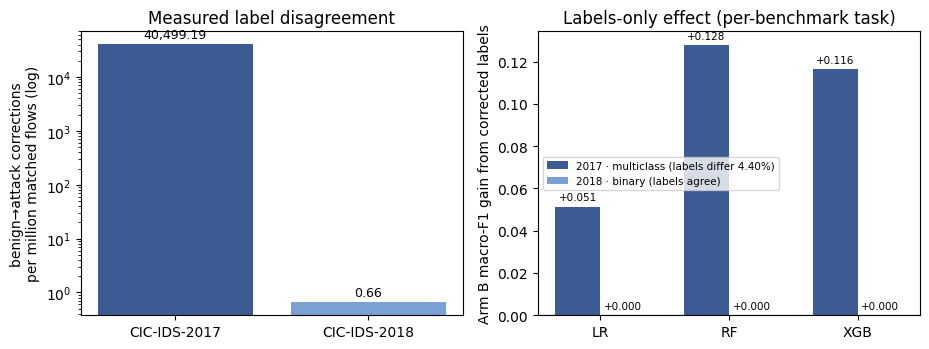

In [4]:
# --- Fig. 6: the cross-dataset dose-response ---------------------------------
# Left: measured label disagreement (benign->attack corrections per million
# matched flows, log scale). Right: the labels-only (Arm B) effect on the same
# benchmark. The effect appears where disagreement exists and vanishes where
# it does not - the method's own negative control.
import matplotlib.pyplot as plt

b2a_per_M = {ds: cross[ds]['benign_to_attack'] / cross[ds]['matched_flows'] * 1e6
             for ds in ['2017', '2018']}

armB = {}
for ds in ['2017', '2018']:
    b = runs[(runs['dataset'] == ds) & (runs['arm'] == 'B') &
             (runs['task'] == 'binary') & (runs['split'] == 'random_70_30')]
    o = b[b['version'] == 'label_original'].groupby('model')['macro_f1'].mean()
    i = b[b['version'] == 'label_improved'].groupby('model')['macro_f1'].mean()
    armB[ds] = (i - o).reindex(['logreg', 'random_forest', 'xgboost', 'mlp'])

# 2017 labels-only effect is measured on multiclass (binary saturates near
# the 0.9997 ceiling and hides it); 2018 has binary only.
mc = runs[(runs['dataset'] == '2017') & (runs['arm'] == 'B') &
          (runs['task'] == 'multiclass') & (runs['split'] == 'random_70_30')]
mo = mc[mc['version'] == 'label_original'].groupby('model')['macro_f1'].mean()
mi = mc[mc['version'] == 'label_improved'].groupby('model')['macro_f1'].mean()
armB17_mc = (mi - mo).reindex(['logreg', 'random_forest', 'xgboost'])

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.6))
ax = axes[0]
ax.bar(['CIC-IDS-2017', 'CIC-IDS-2018'],
       [b2a_per_M['2017'], b2a_per_M['2018']], color=['#3b5b92', '#7aa0d4'])
ax.set_yscale('log')
for x, v in enumerate([b2a_per_M['2017'], b2a_per_M['2018']]):
    ax.text(x, v * 1.3, f'{v:,.2f}', ha='center', fontsize=9)
ax.set_ylabel('benign\u2192attack corrections\nper million matched flows (log)')
ax.set_title('Measured label disagreement')

ax = axes[1]
w = 0.35
models = ['logreg', 'random_forest', 'xgboost']
x = np.arange(len(models))
g17 = armB17_mc.reindex(models).values                 # 2017: multiclass task
g18 = armB['2018'].reindex(models).values              # 2018: binary task
ax.bar(x - w/2, g17, w,
       label='2017 \u00b7 multiclass (labels differ 4.40%)', color='#3b5b92')
ax.bar(x + w/2, g18, w,
       label='2018 \u00b7 binary (labels agree)', color='#7aa0d4')
for xi, v in zip(x - w/2, g17):
    ax.text(xi, v + 0.003, f'{v:+.3f}', ha='center', fontsize=7.5)
for xi, v in zip(x + w/2, g18):
    ax.text(xi, max(v, 0) + 0.003, f'{v:+.3f}', ha='center', fontsize=7.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['LR', 'RF', 'XGB'])
ax.set_ylabel('Arm B macro-F1 gain from corrected labels')
ax.set_title('Labels-only effect (per-benchmark task)')
ax.legend(fontsize=7.5)

fig.tight_layout()
p = os.path.join(C.FIGURES, 'fig6_cross_dataset.png')
fig.savefig(p, dpi=220, bbox_inches='tight')
print('saved', p)
print('\n2017 multiclass Arm B gains (context):')
print(armB17_mc.round(4).to_string())
plt.show()

## Interpreting the replication

Conclusions replicate if, on 2018: (a) disagreement is again strongly
one-directional; (b) Arm A and Arm B deltas carry the same sign as 2017;
(c) the MLP behaves like the other learners rather than rescuing anything.
Where 2018 differs — e.g., a different dominant relabelled class — that is a
finding about the datasets, not a failure of the method. Send
`cross_dataset_headline.json` and I will integrate the replication section
and Table 5 into the manuscript via build_paper.py.